<a href="https://colab.research.google.com/github/S-Meghana13/Customer_Churn_Prediction/blob/main/Placement.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd

In [ ]:
df=pd.read_csv('/content/sample_data/placement-dataset.csv')

In [ ]:
df.head()

,city,cgpa,iq,placement
0,New York,6.8,123.0,1
1,Los Angeles,5.9,106.0,0
2,Chicago,NaN,121.0,0
3,New York,7.4,132.0,1
4,Los Angeles,5.8,142.0,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   cgpa       92 non-null     float64
 1   iq         96 non-null     float64
 2   placement  100 non-null    int64  
dtypes: float64(2), int64(1)
memory usage: 2.5 KB


In [ ]:
df.shape

(100, 4)

In [ ]:
df=df.iloc[:,1:]

In [ ]:
df.head()

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,NaN,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0


In [ ]:
data=df.dropna()

In [ ]:
data.head()

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
3,7.4,132.0,1
4,5.8,142.0,0
5,7.1,48.0,1


In [ ]:
#steps

#0.Preprocess = EDA+Feature Selection
#1.Extract input and output cols
#2.Scale the Values
#3.Train test split
#4.Train the model
#5.Evaluate the Model/Model Selection
#6.Deploy the Model

In [ ]:
import matplotlib.pyplot as plt

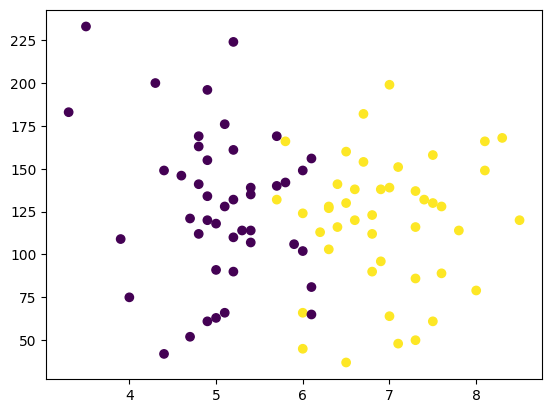

In [ ]:
plt.scatter(data['cgpa'],data['iq'],c=data['placement'])

In [ ]:
x=data.iloc[:,0:2]
y=data.iloc[:,-1]

In [ ]:
x

,cgpa,iq
0,6.8,123.0
1,5.9,106.0
3,7.4,132.0
4,5.8,142.0
5,7.1,48.0
...,...,...
95,4.3,200.0
96,4.4,42.0
97,6.7,182.0
98,6.3,103.0


,placement
0,1
1,0
3,1
4,0
5,1
...,...
95,0
96,0
97,1
98,1


In [ ]:
from sklearn.model_selection import train_test_split

X_train,X_test,Y_train,Y_test=train_test_split(x,y,test_size=0.1)

In [ ]:
X_train

,cgpa,iq
93,6.8,112.0
66,6.9,96.0
47,5.2,161.0
3,7.4,132.0
42,7.6,89.0
...,...,...
11,6.9,138.0
82,6.5,37.0
59,4.8,112.0
41,5.4,114.0


In [ ]:
#Scale values is not necessary.But it scales the values between -1 to 1
from sklearn.preprocessing import StandardScaler

In [ ]:
scaler=StandardScaler()

In [ ]:
X_train = scaler.fit_transform(X_train)

In [ ]:
X_train

array([[ 6.26647479e-01, -2.89613627e-01],
       [ 7.13346517e-01, -6.75358226e-01],
       [-7.60537133e-01,  8.91729207e-01],
       [ 1.14684171e+00,  1.92567122e-01],
       [ 1.32023979e+00, -8.44121488e-01],
       [-2.23442078e+00,  2.62757990e+00],
       [-8.47236171e-01,  9.61309720e-02],
       [-6.73838095e-01, -2.41395552e-01],
       [ 1.66703594e+00, -1.08521186e+00],
       [ 1.32023979e+00,  9.61309720e-02],
       [ 1.92713305e+00,  1.06049247e+00],
       [ 3.66550364e-01,  1.44349047e-01],
       [-1.10733329e+00,  1.08460151e+00],
       [-1.54082848e+00,  1.83198167e+00],
       [-8.47236171e-01, -1.39862935e+00],
       [-7.60537133e-01, -8.20012450e-01],
       [ 2.10053113e+00, -9.67413274e-02],
       [ 1.23354075e+00,  1.44349047e-01],
       [-1.02063425e+00,  2.40785197e-01],
       [-6.69448270e-02, -1.90491913e+00],
       [ 1.93152288e-01,  7.20219346e-02],
       [-1.45412944e+00, -1.97724625e+00],
       [ 8.00045556e-01,  1.80787263e+00],
       [-1.

In [ ]:
X_test = scaler.transform(X_test)

In [ ]:
X_test

array([[-0.58713906,  0.36133038],
       [-0.93393521, -1.47095646],
       [-1.02063425,  0.74707498],
       [-0.76053713,  0.19256712],
       [-0.15364387, -0.43426785],
       [-1.02063425, -1.51917454],
       [ 0.62664748, -0.82001245],
       [-2.40781886,  1.42212803],
       [ 0.4532494 ,  0.33722135]])

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
clf = LogisticRegression()

In [ ]:
#model training
clf.fit(X_train,Y_train)

LogisticRegression()

In [ ]:
Y_pred=clf.predict(X_test)

In [ ]:
Y_test

,placement
12,0
7,0
76,0
19,0
1,0
73,0
35,1
17,0
48,1


In [ ]:
from sklearn.metrics import accuracy_score

In [ ]:
accuracy_score(Y_test,Y_pred)

1.0

In [ ]:
#Decision Boundary
from mlxtend.plotting import plot_decision_regions

<Axes: >

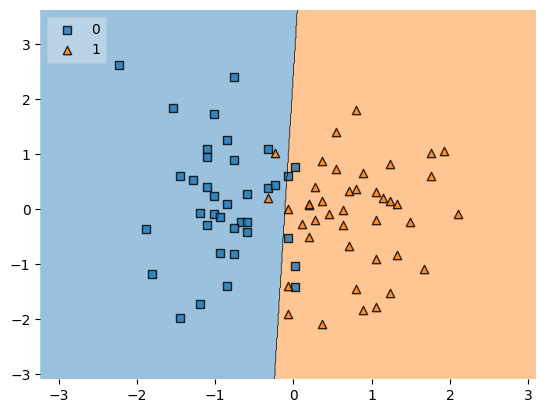

In [ ]:
plot_decision_regions(X_train,Y_train.values,clf=clf,legend=2)

In [ ]:
#pickle is an object.It generates file which are going to be use for Deplyment
import pickle

In [ ]:
pickle.dump(clf,open('model.pkl','wb'))

In [ ]:
#To deploy ml models there are several platforms like Google cloud,aws and Heroku